# Figure 5.1-3 &mdash; the liquefaction path of Illustration 5.1-1

Illustration 5.1-1 liquefies natural gas, and works the whole thing off the methane
$P$&ndash;$\hat H$ chart: *"one follows a line of constant entropy in Fig. 3.3-2, which is
redrawn here with all the stages indicated."* That redrawing is **Figure 5.1-3**, and this
notebook draws it.

The chart itself is Figure 3.3-2, computed from the Peng&ndash;Robinson equation of state; the
machinery lives in `thermo.ph_chart`, so this notebook is only the *path* and the numbers that
go with it. Redraw Fig. 3.3-2 and this figure follows automatically &mdash; which is the point
of having the chart in the package rather than in a chapter&nbsp;3 notebook.

**What the illustration asks.** Methane at 280&nbsp;K and 1&nbsp;bar is compressed to
100&nbsp;bar in three reversible adiabatic stages with intercooling back to 280&nbsp;K, cooled
to 210&nbsp;K, and throttled to 1&nbsp;bar. **(a)** the compressor work, **(b)** the fraction
that liquefies, **(c)** the same by the Linde process, which recycles the cold vapor.

In [1]:
# --- Colab bootstrap -------------------------------------------------------
# No-op when the thermo package is already alongside this notebook (the normal
# case: you cloned the repository and are running from code/ch5/). In Colab there
# is no repository, so fetch the package and the property data.
import os, sys
if not (os.path.isdir('../thermo') or os.path.isdir('thermo')):
    # rm -rf first: git clone REFUSES an existing directory, and under `!` that
    # failure is silent -- a half-finished earlier clone would otherwise leave an
    # empty thermo/ and surface as a baffling ImportError further down.
    !rm -rf /tmp/cbet6e
    !git clone -q --depth 1 https://github.com/emfurst/cbet6e.git /tmp/cbet6e
    !cp -r /tmp/cbet6e/code/thermo /tmp/cbet6e/code/data .
    sys.path.insert(0, '.')
else:
    sys.path.insert(0, '..')
# ---------------------------------------------------------------------------

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from scipy.constants import R
from scipy.optimize import brentq

from thermo.charts import angle_at, use_book_style
from thermo.ph_chart import ChartFluid, isentrope, ph_chart, PREF

use_book_style()          # Computer Modern, with real TeX if it is installed

# Methane on the chart's own basis: kJ/kg, and H = S = 0 for saturated liquid at the
# triple point. Constants from Table 6.6-1, Cp* from the cryogenic Appendix A.II row.
methane = ChartFluid("methane", M=16.043, T_triple=90.69)

## 1. The path, leg by leg

Every leg is computed, not traced. A compressor stage follows a line of constant entropy from
its inlet to the next pressure, so the outlet temperature is *found* &mdash; solve
$\hat S(T,P_{\rm out}) = \hat S(T_{\rm in},P_{\rm in})$ &mdash; rather than read off a chart by
eye. The intercoolers are isobaric, and the throttle is isenthalpic, which is why it draws as a
vertical line.

In [3]:
T_at_SP = lambda S, P, lo=100., hi=900.: brentq(
    lambda t: methane.S(t, P, "vapor") - S, lo, hi, xtol=1e-9)

STAGES = ((1e5, 5e5), (5e5, 25e5), (25e5, 100e5))   # the three compressor stages
legs, nodes = [], []
for k, (Pin, Pout) in enumerate(STAGES, 1):
    H_in, S_in = methane.H(280., Pin, "vapor"), methane.S(280., Pin, "vapor")
    T_out = T_at_SP(S_in, Pout)
    H_out = methane.H(T_out, Pout, "vapor")
    Pg = np.geomspace(Pin, Pout, 140)
    legs.append((f"stage {k} compressor",
                 np.array([methane.H(T_at_SP(S_in, p), p, "vapor") for p in Pg]), Pg/1e6))
    nodes += [(H_in, Pin/1e6), (H_out, Pout/1e6)]
    T_end = 280. if Pout < 100e5 else 210.          # the last cooler goes to 210 K
    Tg = np.linspace(T_out, T_end, 140)
    legs.append((f"stage {k} intercooler" if Pout < 100e5 else "final cooler",
                 np.array([methane.H(t, Pout, "vapor") for t in Tg]),
                 np.full_like(Tg, Pout/1e6)))
    print(f"stage {k}: {Pin/1e5:3g} -> {Pout/1e5:3g} bar   "
          f"Hhat {H_in:6.1f} -> {H_out:6.1f} kJ/kg   T_out {T_out:5.1f} K   "
          f"work {H_out - H_in:5.1f} kJ/kg")
W = sum(l[1][-1] - l[1][0] for l in legs if "compressor" in l[0])

H_jt = methane.H(210., 100e5, "vapor")              # throttling is isenthalpic
# Geometrically two points would do -- it is a straight vertical line -- but
# leg_label picks a plotted point, so give it points to pick from. Geometric
# spacing because the pressure axis is logarithmic.
legs.append(("Joule-Thomson expansion",
             np.full(120, H_jt), np.geomspace(10.0, 0.1, 120)))
nodes.append((H_jt, 0.1))
T_1bar = brentq(lambda t: methane.Psat(t) - 1e5, 95., methane.Tc*0.99)
_, HL, HV, *_ = methane.sat(T_1bar)
x = (H_jt - HL)/(HV - HL)                           # the flash drum
print(f"\ntotal compressor work  {W:.1f} kJ/kg          [the 5e reads 722]")
print(f"after the throttle: Hhat = {H_jt:.1f} kJ/kg, and at 1 bar the dome runs "
      f"{HL:.1f} to {HV:.1f}")
print(f"so the vapor fraction is {x:.3f} and {1-x:.3f} of the feed liquefies  "
      f"[the 5e reads 0.826 / 0.174]")

stage 1:   1 ->   5 bar   Hhat  936.9 -> 1218.1 kJ/kg   T_out 401.0 K   work 281.2 kJ/kg
stage 2:   5 ->  25 bar   Hhat  931.9 -> 1210.4 kJ/kg   T_out 403.2 K   work 278.5 kJ/kg
stage 3:  25 -> 100 bar   Hhat  906.4 -> 1130.3 kJ/kg   T_out 390.5 K   work 223.9 kJ/kg

total compressor work  783.6 kJ/kg          [the 5e reads 722]
after the throttle: Hhat = 495.2 kJ/kg, and at 1 bar the dome runs 69.9 to 579.6
so the vapor fraction is 0.834 and 0.166 of the feed liquefies  [the 5e reads 0.826 / 0.174]


## 2. Figure 5.1-3

**The frame is wider than Fig. 3.3-2's, and has to be.** Two compressor stages now end at
1218 and 1210&nbsp;kJ/kg, past the 1200 the parent chart stops at &mdash; and the corner where
each compressor meets its intercooler is the thing this figure exists to show. (The 5e read
1195 and 1180 off its chart, which just fitted.) The floor drops from 0.1 to 0.08&nbsp;MPa for
the same reason: two states sit exactly at 1&nbsp;bar and would otherwise be cut in half by the
axis. Neither change touches Fig. 3.3-2 itself.

The chart is also drawn **sparser** than its parent: no constant-volume family (the
illustration never uses one) and the isentropes left light and unlabeled, because the three
compressor legs *are* isentropes and a labeled family beside them invites reading the path off
the wrong curve.

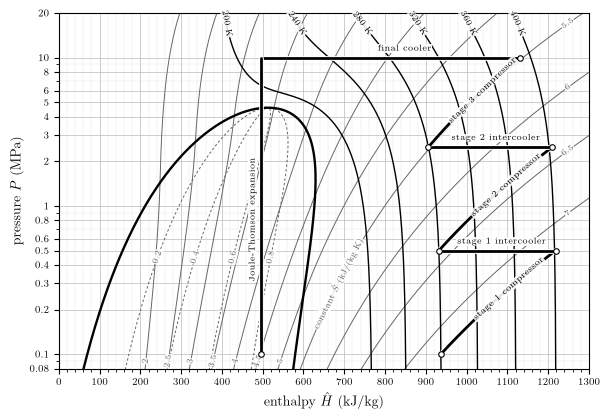

In [4]:
# ART SLOT c05f003 -- Figure 5.1-3. 6.2 x 4.3 in against the 5e's 4.9 x 3.6, which
# crammed the whole of Fig. 3.3-2 in and was barely readable.
MET513 = dict(H_lim=(0, 1300), P_lim=(0.08, 20), H_grid=100,
              isotherms=(200, 240, 280, 320, 360, 400), isotherms_minor=(),
              isentropes=[2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0, 6.5, 7.0], volumes=(),
              qualities=(0.2, 0.4, 0.6, 0.8),
              T_label_P=17, x_label_P=0.45, S_label_P={},
              label_fmt={"T": "{:g} K"},
              family_labels=[("S", 5.5, 0.30, "constant $\\hat S$ (kJ/(kg K)")])

fig, ax = plt.subplots(figsize=(6.2, 4.3))
ph_chart(ax, methane, **MET513)
HALO = [pe.withStroke(linewidth=3.4, foreground="white")]   # the path over the chart
for _, H, P in legs:
    ax.plot(H, P, "-", color="k", lw=2.0, zorder=7, path_effects=HALO,
            solid_capstyle="round", solid_joinstyle="round")
for H, P in nodes:
    ax.plot([H], [P], "o", mfc="white", mec="k", mew=0.8, ms=4.0, zorder=8)


def leg_label(name, frac, dx=0, dy=0.0, size=5.8, rot=None):
    """Write a leg's own name along it.

    frac  where along the leg: 0 at its start, 1 at its end. It selects one of the
          leg's PLOTTED POINTS, so a leg drawn with only two of them can only ever
          be labeled at one end or the other -- hence the assert.
    dx    shift in enthalpy, kJ/kg, added. The x axis is linear.
    dy    shift in pressure, as a FRACTION of it: P*(1 + dy). The y axis is
          logarithmic, so one value gives the same visual gap at any pressure --
          which is why 0.15 lifts all three horizontal legs equally clear of their
          own lines. Use dy = 0 to put the text on the line and break it, the way
          the compressor labels and the chart's own curve labels do.
    rot   None follows the curve's tangent there; a number overrides it.
    """
    H, P = next((h, p) for n, h, p in legs if n == name)
    assert len(H) > 2, f"{name!r} is drawn with {len(H)} points, so frac cannot " \
                       f"place a label along it -- give the leg more points"
    i = int(frac*(len(H) - 1))
    a = angle_at(ax, H, P, min(max(i, 1), len(H) - 2)) if rot is None else rot
    ax.text(H[i] + dx, P[i]*(1 + dy), name, fontsize=size, ha="center", va="center",
            rotation=a, rotation_mode="anchor", zorder=9,
            bbox=dict(fc="white", ec="none", pad=0.6, alpha=0.9))


for k in (1, 2, 3):
    leg_label(f"stage {k} compressor", 0.64)
leg_label("stage 1 intercooler", 0.45, dy=0.15, rot=0)
leg_label("stage 2 intercooler", 0.45, dy=0.15, rot=0)
leg_label("final cooler", 0.55, dy=0.15, rot=0)
leg_label("Joule-Thomson expansion", 0.55, dx=-20, rot=90)   # ~2.6 MPa
fig.tight_layout()
os.makedirs("pdf", exist_ok=True)
fig.savefig("pdf/Fig_5.1-3.pdf")                    # the printed figure
plt.show()

## 3. Does it agree with anything? Illustration 5.1-1 against the book's own Aspen run

The illustration carries an **Aspen Plus Peng&ndash;Robinson simulation** of parts (a) and (b),
and the 5e prints its output &mdash; $281.3 + 260.6 + 224.0 = 765.9$ kJ/kg, liquid fraction
0.164. The chart-read numbers in the illustration's own text are $255 + 242 + 225 = 722$ and
0.174. **The 5e never reconciles the two.**

This is the check that says whether the recomputed chart is right, so it lives with the figure.
The answer: the recompute lands on **Aspen**, not on the printed text.

In [5]:
def _stage(Tin, Pin, Pout):
    """(work kJ/kg, outlet T) for one reversible adiabatic compressor stage."""
    T_out = T_at_SP(methane.S(Tin, Pin, "vapor"), Pout)
    return methane.H(T_out, Pout, "vapor") - methane.H(Tin, Pin, "vapor"), T_out


# the same stage, for an IDEAL gas, using this chart's own Cp*
_cp, _M = methane.cp, methane.M
_Hig = lambda T: sum(c*T**(i + 1)/(i + 1) for i, c in enumerate(_cp))/_M   # J/mol / (g/mol) = kJ/kg
_Sig = lambda T, P: (sum(c*T**i/i if i else c*np.log(T) for i, c in enumerate(_cp))
                     - R*np.log(P/PREF))/_M


def _stage_ig(Tin, Pin, Pout):
    T_out = brentq(lambda t: _Sig(t, Pout) - _Sig(Tin, Pin), 150., 900.)
    return _Hig(T_out) - _Hig(Tin), T_out


ASPEN = (281.3, 260.6, 224.0)          # the 5e's printed Aspen PR output
CHART = (255.0, 242.0, 225.0)          # what the 5e read off the licensed chart
print(f"{'stage':<22}{'ideal gas':>11}{'this chart':>12}{'5e Aspen PR':>13}{'5e chart':>10}")
for k, (Pin, Pout) in enumerate(STAGES, 1):
    w, _ = _stage(280., Pin, Pout)
    w_ig, _ = _stage_ig(280., Pin, Pout)
    print(f"{k}: {Pin/1e5:g} -> {Pout/1e5:g} bar" .ljust(22)
          + f"{w_ig:11.1f}{w:12.1f}{ASPEN[k-1]:13.1f}{CHART[k-1]:10.1f}")
print(" total".ljust(22) + f"{'':11}{W:12.1f}{sum(ASPEN):13.1f}{sum(CHART):10.1f}")
print(f" liquefied fraction".ljust(22) + f"{'':11}{1-x:12.3f}{0.164:13.3f}{0.174:10.3f}")

print("\nStages 1 and 3 sit on Aspen to 0.04 %, and so does the liquefied fraction.")
print("Stage 2 does not -- and stage 2 is the one that CANNOT differ from stage 1 by much:")
print("same pressure ratio, same 280 K inlet, so the ideal gas gives them identical work.")
_f = lambda T: _stage(T, 5e5, 25e5)[0] - ASPEN[1]
_g = lambda P: _stage(280., 5e5, P)[0] - ASPEN[1]
print(f"  reproducing Aspen's 260.6 needs an inlet of {brentq(_f, 200., 300.):.1f} K "
      f"or a discharge of {brentq(_g, 6e5, 25e5)/1e5:.1f} bar;")
print("  the problem statement says 280 K and 25 bar. Suspect the second intercooler in the"
      " flowsheet.")

stage                   ideal gas  this chart  5e Aspen PR  5e chart
1: 1 -> 5 bar               282.0       281.2        281.3     255.0
2: 5 -> 25 bar              282.0       278.5        260.6     242.0
3: 25 -> 100 bar            236.7       223.9        224.0     225.0
 total                                  783.6        765.9     722.0
 liquefied fraction                     0.166        0.164     0.174

Stages 1 and 3 sit on Aspen to 0.04 %, and so does the liquefied fraction.
Stage 2 does not -- and stage 2 is the one that CANNOT differ from stage 1 by much:
same pressure ratio, same 280 K inlet, so the ideal gas gives them identical work.
  reproducing Aspen's 260.6 needs an inlet of 261.9 K or a discharge of 22.9 bar;
  the problem statement says 280 K and 25 bar. Suspect the second intercooler in the flowsheet.


## 4. Part (c) &mdash; the Linde process

**The trap, and it caught an earlier pass of these notes.** Part (a)'s compressor work does
**not** carry over: in the Linde process the compressor is fed the **cold recycle mixed with
fresh make-up**, not the 280&nbsp;K feed, so its first stage does much less work.

In [6]:
H_recycle = methane.H(200., 1e5, "vapor")        # recycle leaves the exchanger at 1 bar, 200 K
H_fresh = methane.H(280., 1e5, "vapor")
omega = (H_jt - HL)/(H_recycle - HL)             # mass fraction recycled
H_mix = omega*H_recycle + (1 - omega)*H_fresh    # what the compressor actually sees
T_mix = brentq(lambda t: methane.H(t, 1e5, "vapor") - H_mix, 150., 300.)
W1_L, T1_L = _stage(T_mix, 1e5, 5e5)
W2_L, W3_L = _stage(280., 5e5, 25e5)[0], _stage(280., 25e5, 100e5)[0]
W_L = W1_L + W2_L + W3_L

print(f"  recycle fraction {omega:.3f}, so {1-omega:.3f} liquefies      [the 5e reads 0.604 / 0.396]")
print(f"  compressor inlet is the MIXED stream: {H_mix:.1f} kJ/kg at {T_mix:.1f} K"
      f"   [the 5e reads 837 at 233 K]")
print(f"  stage 1 from there: {W1_L:.1f} kJ/kg, out at {T1_L:.1f} K"
      f"        [the 5e reads 183 kJ/kg at 388 K --")
print(f"      388 K is the part-(a) outlet, from an inlet 47 K warmer; it cannot also be this one]")
print(f"  total {W_L:.1f} kJ/kg -> {W_L/(1-omega):.0f} kJ per kg LNG      [the 5e reads 650 -> 1641]")
print(f"  simple process, for comparison: {W/(1-x):.0f} kJ per kg LNG    [the 5e reads 4149]")
print(f"\n  Linde advantage {(W/(1-x))/(W_L/(1-omega)):.2f}x   [the 5e gets 2.53x] -- the Comment's"
      f" \"about 40 percent\" still holds")

  recycle fraction 0.611, so 0.389 liquefies      [the 5e reads 0.604 / 0.396]
  compressor inlet is the MIXED stream: 832.4 kJ/kg at 231.6 K   [the 5e reads 837 at 233 K]
  stage 1 from there: 234.4 kJ/kg, out at 339.0 K        [the 5e reads 183 kJ/kg at 388 K --
      388 K is the part-(a) outlet, from an inlet 47 K warmer; it cannot also be this one]
  total 736.8 kJ/kg -> 1894 kJ per kg LNG      [the 5e reads 650 -> 1641]
  simple process, for comparison: 4730 kJ per kg LNG    [the 5e reads 4149]

  Linde advantage 2.50x   [the 5e gets 2.53x] -- the Comment's "about 40 percent" still holds


## What this notebook shows

- **Figure 5.1-3**, the liquefaction path on the methane chart, computed rather than traced.
- The recomputed numbers agree with the illustration's **own Aspen simulation** on every
  quantity Aspen reports correctly &mdash; stages 1 and 3 to 0.04 %, and the liquefied fraction
  &mdash; while the 5e's chart reads agree with none of it.
- **Aspen's stage 2 is the one number out of line with both**, and it cannot be right: same
  pressure ratio and same inlet temperature as stage 1, so their work must be nearly equal.
  Worth opening the flowsheet's second intercooler before anything is printed.
- The *Comment*'s **"about 40 percent"** survives: the Linde advantage is 2.50&times; against
  the 5e's 2.53&times;.

## Your turn

- The final cooler stops at 210&nbsp;K. Push it colder and watch the liquefied fraction rise
  &mdash; at what temperature would half the feed liquefy, and what would that cost in heat
  exchange?
- Change the intercooling: what if the intercoolers only reach 300&nbsp;K on a hot day?
- The recycle in part (c) returns at 200&nbsp;K. That is a heat-exchanger design choice, not
  thermodynamics. Sweep it and find where the Linde advantage stops improving.